# Midstance Entropy & Loading Rate — Visual Dashboard

All charts show **Left and Right foot on the same axes**, with Midstance Entropy
and Loading Rate displayed **side-by-side** for direct comparison.

| Chart | What it shows |
|---|---|
| Line graph | Metric over walk time — trend and variability |
| Scatter plot | Step-by-step values, left vs right symmetry |
| Bar chart | Per-step magnitude, left vs right interleaved |
| Rolling mean | Smoothed trend ± 1 SD band |
| Box plot | Full distribution per foot |
| Histogram | Distribution shape and overlap |
| Cumulative dist. | Where each foot sits relative to the other |
| Step symmetry | Absolute difference per matched step pair |

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.stats import entropy as scipy_entropy, mannwhitneyu
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.size'       : 10,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'grid.linestyle'  : ':',
})

print('Ready')

Ready


## Cell 2 — Configuration

In [2]:
CSV_PATH = 'Kristian_dry_0425.csv'

PRESSURE_COLS     = [f'pressure_{i:02d}' for i in range(1, 13)]
HEEL_SENSORS      = ['pressure_08', 'pressure_11']
MAX_ENTROPY       = np.log2(12)
SAMPLE_RATE_MS    = 4

# Stance detection
STANCE_PERCENTILE = 15
MIN_STANCE_SAMP   = 20
MAX_STANCE_SAMP   = 500
MS_START, MS_END  = 1/3, 2/3

# Loading rate (v7)
SMOOTH_WIN    = 11
SMOOTH_POLY   = 2
BIG_PEAK_DIST = 50
BIG_PEAK_PROM = 200
BIG_PEAK_HT   = 500
HILL_WINDOW   = 10
MIN_DP        = 5

# Colours — consistent across every chart
C_RIGHT = '#1F77B4'   # blue
C_LEFT  = '#FF7F0E'   # orange
ALPHA   = 0.75

print('Config ready')

Config ready


## Cell 3 — Load & Extract Both Metrics

In [3]:
raw = pd.read_csv(CSV_PATH, low_memory=False)
raw = raw[raw['corrupt'] == 0].copy()
raw['timestamp']      = pd.to_numeric(raw['timestamp'], errors='coerce')
raw['total_pressure'] = raw[PRESSURE_COLS].sum(axis=1)

# ── helpers ───────────────────────────────────────────────────────────────────
def detect_stances(sdf):
    sig = sdf['total_pressure'].values
    thr = np.percentile(sig, STANCE_PERCENTILE)
    in_s = sig >= thr
    wins, i = [], 0
    while i < len(in_s):
        if in_s[i]:
            s = i
            while i < len(in_s) and in_s[i]: i += 1
            d = i - s
            if MIN_STANCE_SAMP <= d <= MAX_STANCE_SAMP:
                wins.append({'start': s, 'end': i, 'duration': d})
        else:
            i += 1
    return wins

def extract_entropy(sdf, foot_label):
    wins = detect_stances(sdf)
    recs = []
    t0   = sdf['timestamp'].iloc[0]
    for idx, win in enumerate(wins):
        s, e, d = win['start'], win['end'], win['duration']
        ms_s = s + int(d * MS_START)
        ms_e = s + int(d * MS_END)
        if ms_e <= ms_s: continue
        mp  = sdf.iloc[ms_s:ms_e][PRESSURE_COLS].mean().values.astype(float)
        tot = mp.sum()
        if tot < 10: continue
        p = np.clip(mp / tot, 1e-10, 1.0)
        H = scipy_entropy(p, base=2)
        t = (sdf.iloc[(ms_s + ms_e) // 2]['timestamp'] - t0) / 1000
        recs.append({
            'step': idx, 'foot': foot_label, 'time_s': t,
            'evenness': H / MAX_ENTROPY,
            'H_bits': H,
            'unevenness': 1 - H / MAX_ENTROPY,
            'stance_ms': d * SAMPLE_RATE_MS,
        })
    return pd.DataFrame(recs)

def find_step_windows(sdf):
    y = sum(pd.to_numeric(sdf[s], errors='coerce').fillna(0).to_numpy(dtype=float)
            for s in HEEL_SENSORS if s in sdf.columns)
    n  = len(y)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY: sw = SMOOTH_POLY + 3 + (1 if (SMOOTH_POLY + 3) % 2 == 0 else 0)
    ys = savgol_filter(y, window_length=sw, polyorder=min(SMOOTH_POLY, sw - 1))
    pk, _ = find_peaks(ys, distance=BIG_PEAK_DIST,
                        prominence=BIG_PEAK_PROM, height=BIG_PEAK_HT)
    return pk

def extract_lr(sdf, foot_label):
    t0  = sdf['timestamp'].iloc[0]
    t   = (sdf['timestamp'] - t0).to_numpy() / 1000
    big = find_step_windows(sdf)
    recs = []
    for sensor in HEEL_SENSORS:
        y = pd.to_numeric(sdf[sensor], errors='coerce').to_numpy(dtype=float)
        for i in range(len(big) - 1):
            p1, p2 = big[i], big[i + 1]
            ci  = p1 + int(np.argmin(y[p1:p2]))
            end = min(p2, ci + HILL_WINDOW)
            seg = y[ci:end + 1]
            lp, _ = find_peaks(seg, prominence=1)
            hi  = ci + (lp[0] if len(lp) else int(np.argmax(seg[1:])) + 1)
            dt  = t[hi] - t[ci]
            dp  = y[hi]  - y[ci]
            if dt <= 0 or dp < MIN_DP: continue
            recs.append({'foot': foot_label, 'sensor': sensor, 'window_id': i,
                         'time_s': t[ci], 'loading_rate': dp / dt,
                         'pressure_rise': dp, 'time_to_peak_ms': dt * 1000})
    if not recs: return pd.DataFrame()
    all_res = pd.DataFrame(recs)
    avg = (all_res.groupby(['foot', 'window_id'], as_index=False)
           .agg(time_s          = ('time_s',          'mean'),
                loading_rate    = ('loading_rate',    'mean'),
                pressure_rise   = ('pressure_rise',   'mean'),
                time_to_peak_ms = ('time_to_peak_ms', 'mean'),
                n_sensors       = ('sensor',          'count'))
           .pipe(lambda d: d[d['n_sensors'] == len(HEEL_SENSORS)])
           .drop(columns='window_id').reset_index(drop=True))
    avg['step'] = range(1, len(avg) + 1)
    return avg

# ── run extraction ────────────────────────────────────────────────────────────
ent_list, lr_list = [], []
for sid, label in [(1, 'Right'), (2, 'Left')]:
    sdf = raw[raw['sole_id'] == sid].sort_values('timestamp').reset_index(drop=True)
    ent_list.append(extract_entropy(sdf, label))
    lr_list.append(extract_lr(sdf, label))

ent = pd.concat(ent_list, ignore_index=True)
lr  = pd.concat(lr_list,  ignore_index=True)

# Reset step index to walk-time order within each foot
for df_ref in [ent, lr]:
    df_ref.sort_values(['foot', 'time_s'], inplace=True)
    df_ref['step_n'] = df_ref.groupby('foot').cumcount() + 1
    df_ref.reset_index(drop=True, inplace=True)

for label, col in [('Evenness', 'evenness'), ('H bits', 'H_bits')]:
    for foot in ['Right', 'Left']:
        v = ent[ent.foot == foot][col]
        print(f'  Entropy {label} {foot:5s}: {v.mean():.4f} ± {v.std():.4f}')

print()
for foot in ['Right', 'Left']:
    v = lr[lr.foot == foot]['loading_rate']
    print(f'  LR {foot:5s}: {v.mean():.0f} ± {v.std():.0f}  [{v.min():.0f}–{v.max():.0f}]')

  Entropy Evenness Right: 0.9875 ± 0.0043
  Entropy Evenness Left : 0.9906 ± 0.0023
  Entropy H bits Right: 3.5401 ± 0.0154
  Entropy H bits Left : 3.5512 ± 0.0082

  LR Right: 1196 ± 381  [240–2870]
  LR Left : 939 ± 347  [281–2125]


## Cell 4 — Helper: side-by-side figure factory
Every chart is created with a shared factory so layout, colours, and labels stay
consistent across all eight plots.

In [4]:
def make_fig(title, figsize=(14, 4.5)):
    """Return (fig, ax_ent, ax_lr) for a side-by-side chart pair."""
    fig, (ax_e, ax_l) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    ax_e.set_title('Midstance Evenness Score', fontsize=11)
    ax_l.set_title('Heel-Strike Loading Rate  (pressure units / s)', fontsize=11)
    for ax in (ax_e, ax_l):
        ax.tick_params(labelsize=9)
    return fig, ax_e, ax_l

def foot_patches():
    return [
        mpatches.Patch(color=C_RIGHT, label='Right foot', alpha=ALPHA),
        mpatches.Patch(color=C_LEFT,  label='Left foot',  alpha=ALPHA),
    ]

def save(fig, name):
    fig.savefig(name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {name}')

print('Helpers ready')

Helpers ready


## Cell 5 — Chart 1: Line Graph — Metric vs Walk Time

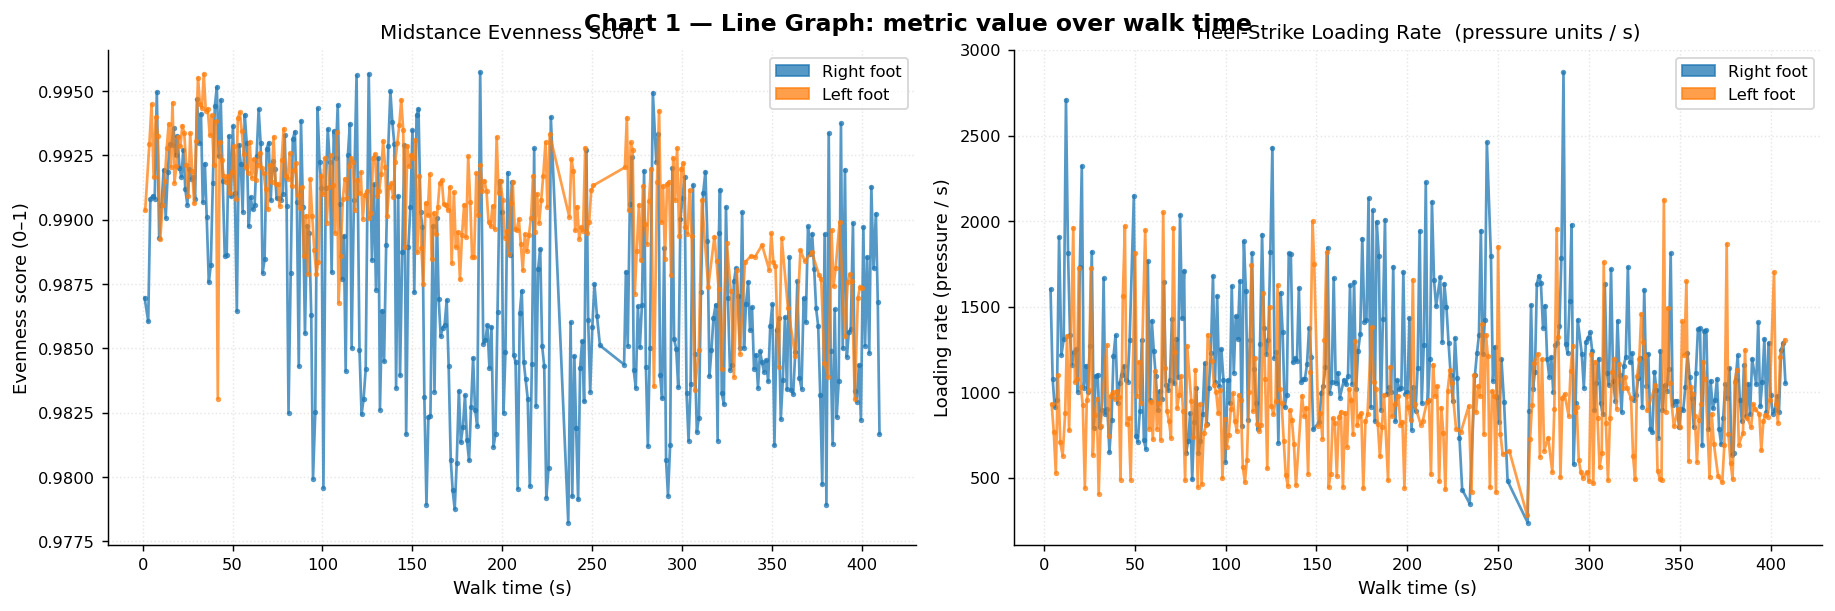

Saved → chart1_line.png


In [5]:
fig, ax_e, ax_l = make_fig('Chart 1 — Line Graph: metric value over walk time')

for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
    d = ent[ent.foot == foot].sort_values('time_s')
    ax_e.plot(d['time_s'], d['evenness'], color=color, lw=1.5,
              alpha=ALPHA, label=foot, marker='o', ms=3, markeredgewidth=0)

ax_e.set_xlabel('Walk time (s)')
ax_e.set_ylabel('Evenness score (0–1)')
ax_e.legend(handles=foot_patches(), fontsize=9)

for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
    d = lr[lr.foot == foot].sort_values('time_s')
    ax_l.plot(d['time_s'], d['loading_rate'], color=color, lw=1.5,
              alpha=ALPHA, label=foot, marker='o', ms=3, markeredgewidth=0)

ax_l.set_xlabel('Walk time (s)')
ax_l.set_ylabel('Loading rate (pressure / s)')
ax_l.legend(handles=foot_patches(), fontsize=9)

save(fig, 'chart1_line.png')

## Cell 6 — Chart 2: Scatter Plot — Value vs Step Number

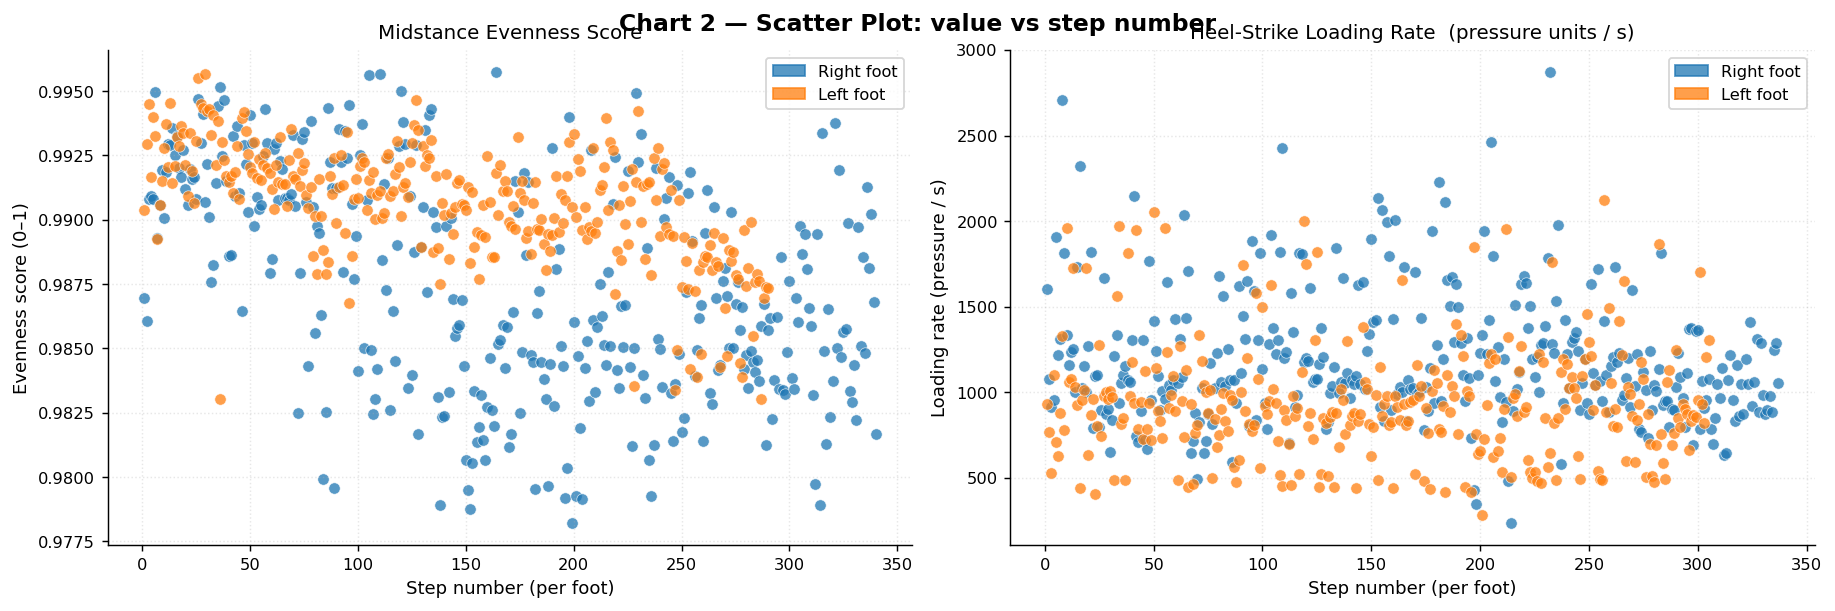

Saved → chart2_scatter.png


In [6]:
fig, ax_e, ax_l = make_fig('Chart 2 — Scatter Plot: value vs step number')

for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
    d = ent[ent.foot == foot]
    ax_e.scatter(d['step_n'], d['evenness'], color=color,
                 alpha=ALPHA, s=40, edgecolors='white', linewidths=0.4)

ax_e.set_xlabel('Step number (per foot)')
ax_e.set_ylabel('Evenness score (0–1)')
ax_e.legend(handles=foot_patches(), fontsize=9)

for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
    d = lr[lr.foot == foot]
    ax_l.scatter(d['step_n'], d['loading_rate'], color=color,
                 alpha=ALPHA, s=40, edgecolors='white', linewidths=0.4)

ax_l.set_xlabel('Step number (per foot)')
ax_l.set_ylabel('Loading rate (pressure / s)')
ax_l.legend(handles=foot_patches(), fontsize=9)

save(fig, 'chart2_scatter.png')

## Cell 7 — Chart 3: Interleaved Bar Chart — Per-Step Magnitude

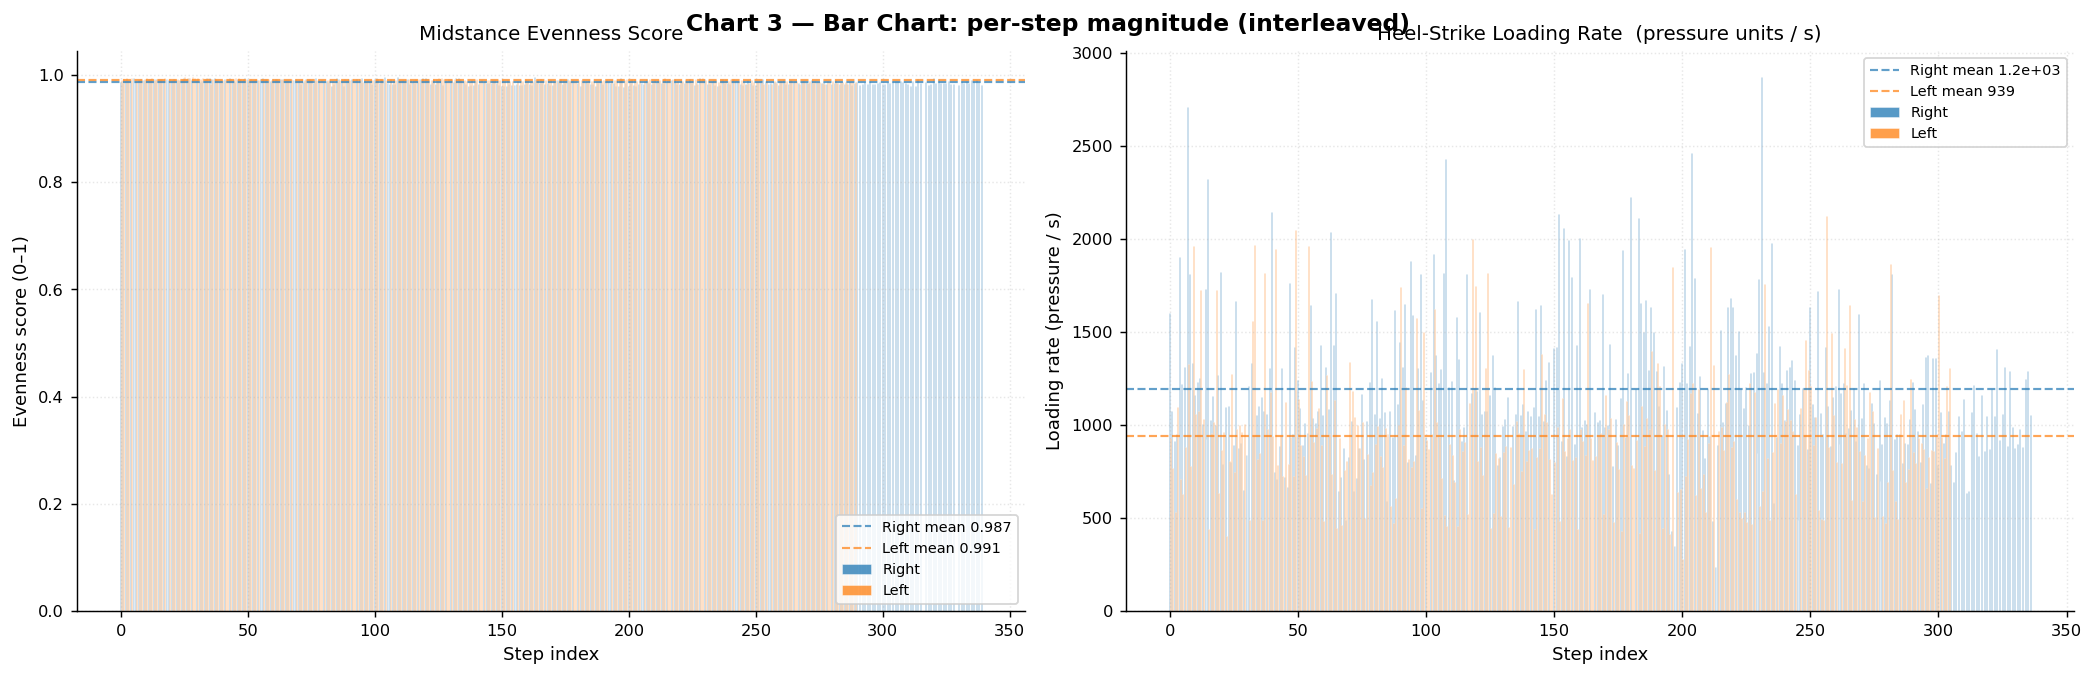

Saved → chart3_bar.png


In [7]:
fig, ax_e, ax_l = make_fig('Chart 3 — Bar Chart: per-step magnitude (interleaved)', figsize=(16, 5))

for ax, df_m, metric, ylabel in [
    (ax_e, ent, 'evenness',     'Evenness score (0–1)'),
    (ax_l, lr,  'loading_rate', 'Loading rate (pressure / s)'),
]:
    r = df_m[df_m.foot == 'Right'].reset_index(drop=True)
    l = df_m[df_m.foot == 'Left'].reset_index(drop=True)
    n = max(len(r), len(l))
    x = np.arange(n)
    w = 0.38

    ax.bar(x[:len(r)] - w/2, r[metric], width=w,
           color=C_RIGHT, alpha=ALPHA, label='Right', edgecolor='white', linewidth=0.3)
    ax.bar(x[:len(l)] + w/2, l[metric], width=w,
           color=C_LEFT,  alpha=ALPHA, label='Left',  edgecolor='white', linewidth=0.3)

    ax.axhline(r[metric].mean(), color=C_RIGHT, ls='--', lw=1.2, alpha=0.7,
               label=f'Right mean {r[metric].mean():.3g}')
    ax.axhline(l[metric].mean(), color=C_LEFT,  ls='--', lw=1.2, alpha=0.7,
               label=f'Left mean {l[metric].mean():.3g}')

    ax.set_xlabel('Step index')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

save(fig, 'chart3_bar.png')

## Cell 8 — Chart 4: Rolling Mean ± 1 SD Band

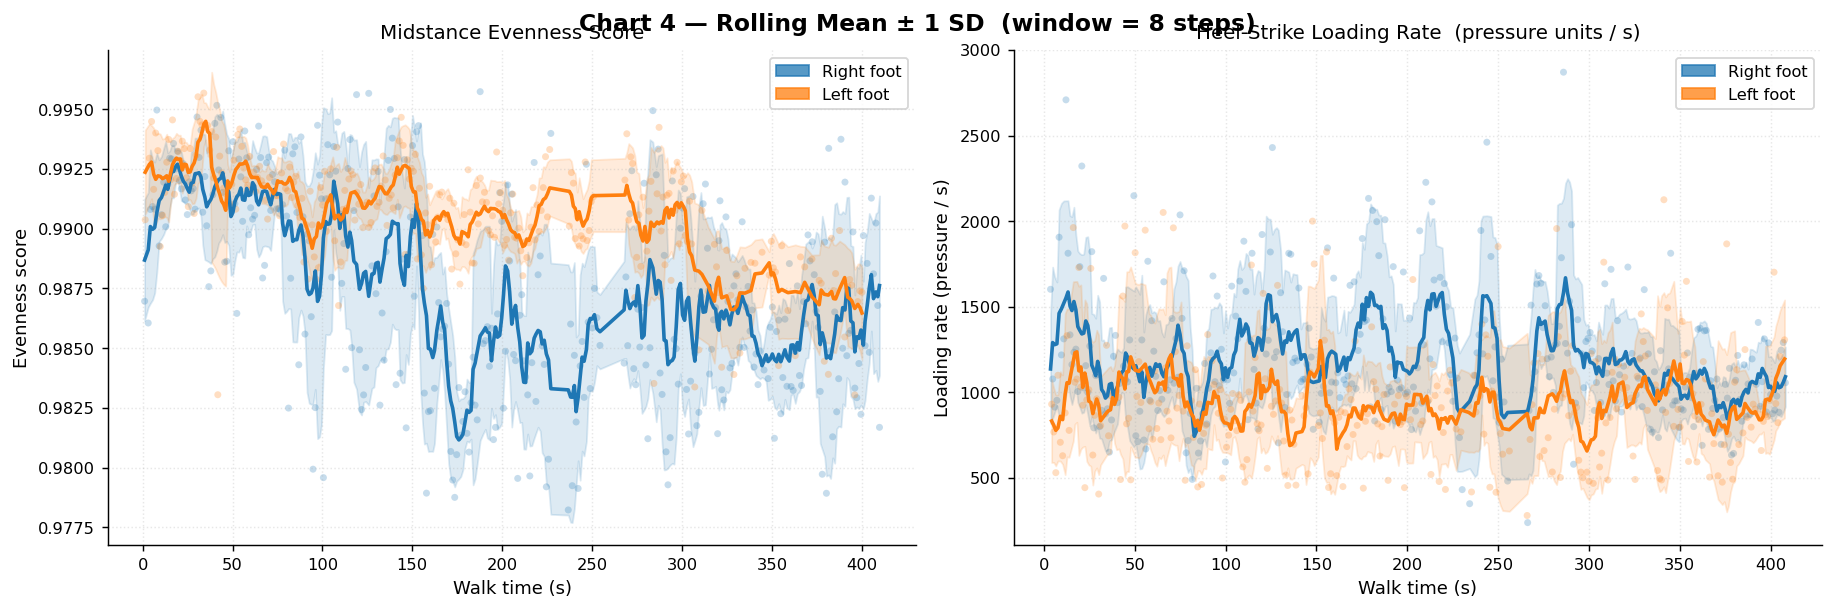

Saved → chart4_rolling.png


In [8]:
ROLL = 8   # window size in steps

fig, ax_e, ax_l = make_fig(f'Chart 4 — Rolling Mean ± 1 SD  (window = {ROLL} steps)')

for ax, df_m, metric, ylabel in [
    (ax_e, ent, 'evenness',     'Evenness score'),
    (ax_l, lr,  'loading_rate', 'Loading rate (pressure / s)'),
]:
    for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
        d  = df_m[df_m.foot == foot].sort_values('time_s').reset_index(drop=True)
        mn = d[metric].rolling(ROLL, center=True, min_periods=3).mean()
        sd = d[metric].rolling(ROLL, center=True, min_periods=3).std()

        ax.plot(d['time_s'], mn, color=color, lw=2, label=foot)
        ax.fill_between(d['time_s'], mn - sd, mn + sd,
                        color=color, alpha=0.15)
        # raw dots behind the line
        ax.scatter(d['time_s'], d[metric], color=color,
                   alpha=0.25, s=15, edgecolors='none')

    ax.set_xlabel('Walk time (s)')
    ax.set_ylabel(ylabel)
    ax.legend(handles=foot_patches(), fontsize=9)

save(fig, 'chart4_rolling.png')

## Cell 9 — Chart 5: Box Plot — Distribution per Foot

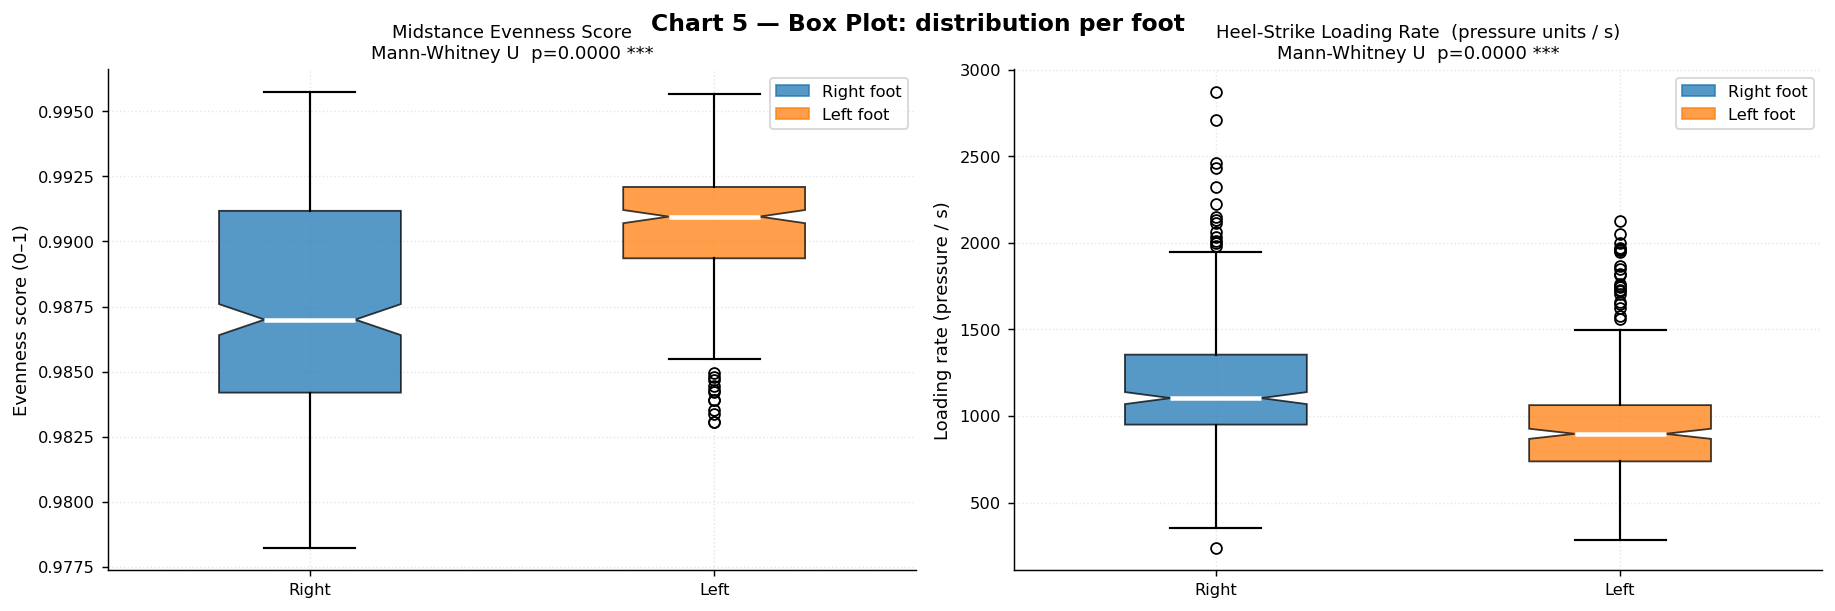

Saved → chart5_boxplot.png


In [9]:
fig, ax_e, ax_l = make_fig('Chart 5 — Box Plot: distribution per foot')

for ax, df_m, metric, ylabel in [
    (ax_e, ent, 'evenness',     'Evenness score (0–1)'),
    (ax_l, lr,  'loading_rate', 'Loading rate (pressure / s)'),
]:
    groups = [df_m[df_m.foot == f][metric].values for f in ['Right', 'Left']]
    bp = ax.boxplot(groups, patch_artist=True, notch=True, widths=0.45,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    for patch, color in zip(bp['boxes'], [C_RIGHT, C_LEFT]):
        patch.set_facecolor(color)
        patch.set_alpha(ALPHA)

    # Mann-Whitney U test
    stat, p = mannwhitneyu(*groups, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(ax.get_title() + f'\nMann-Whitney U  p={p:.4f} {sig}', fontsize=10)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Right', 'Left'])
    ax.set_ylabel(ylabel)
    ax.legend(handles=foot_patches(), fontsize=9)

save(fig, 'chart5_boxplot.png')

## Cell 10 — Chart 6: Overlapping Histogram

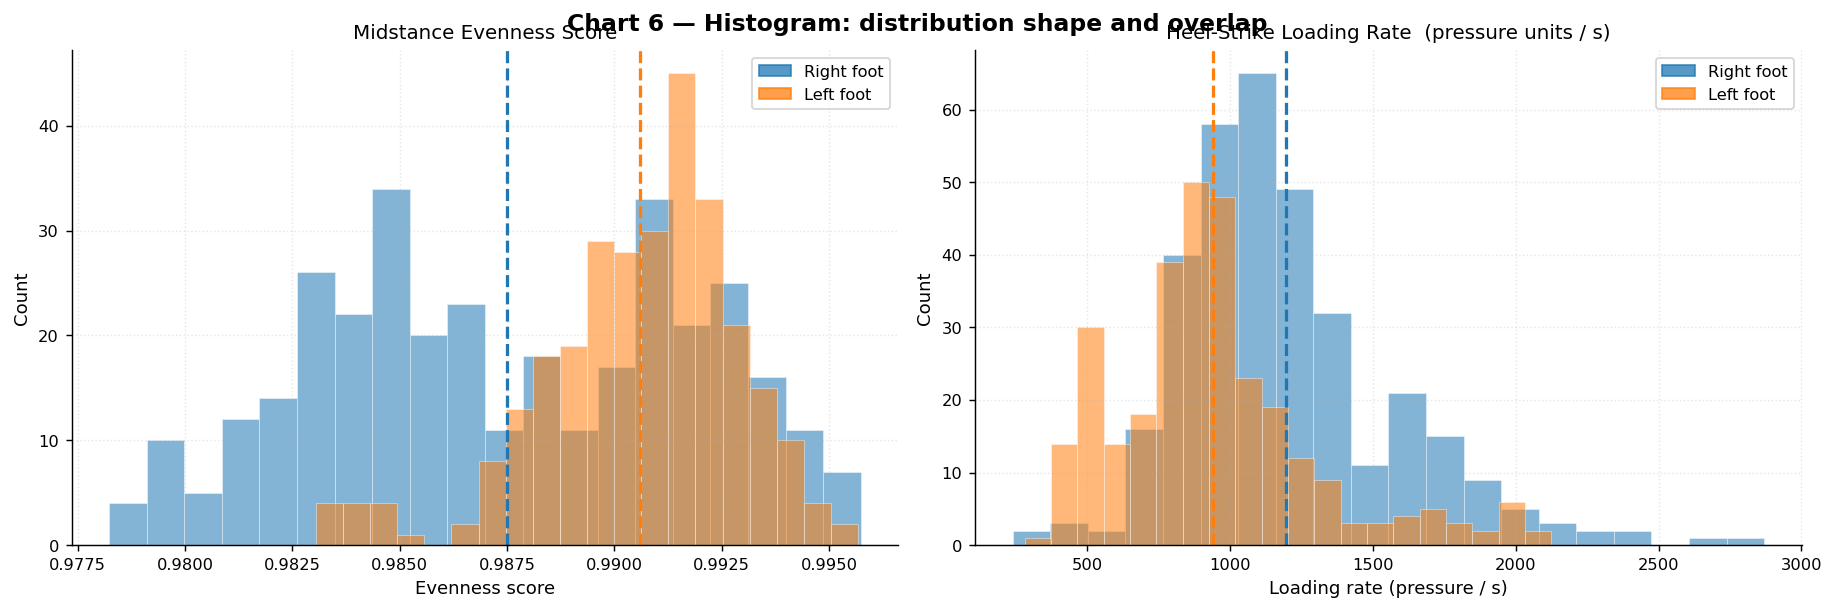

Saved → chart6_histogram.png


In [10]:
fig, ax_e, ax_l = make_fig('Chart 6 — Histogram: distribution shape and overlap')

for ax, df_m, metric, xlabel in [
    (ax_e, ent, 'evenness',     'Evenness score'),
    (ax_l, lr,  'loading_rate', 'Loading rate (pressure / s)'),
]:
    for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
        vals = df_m[df_m.foot == foot][metric].values
        ax.hist(vals, bins=20, color=color, alpha=0.55,
                label=foot, edgecolor='white', linewidth=0.4)
        ax.axvline(vals.mean(), color=color, lw=1.8, ls='--')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(handles=foot_patches(), fontsize=9)

save(fig, 'chart6_histogram.png')

## Cell 11 — Chart 7: Cumulative Distribution (ECDF)

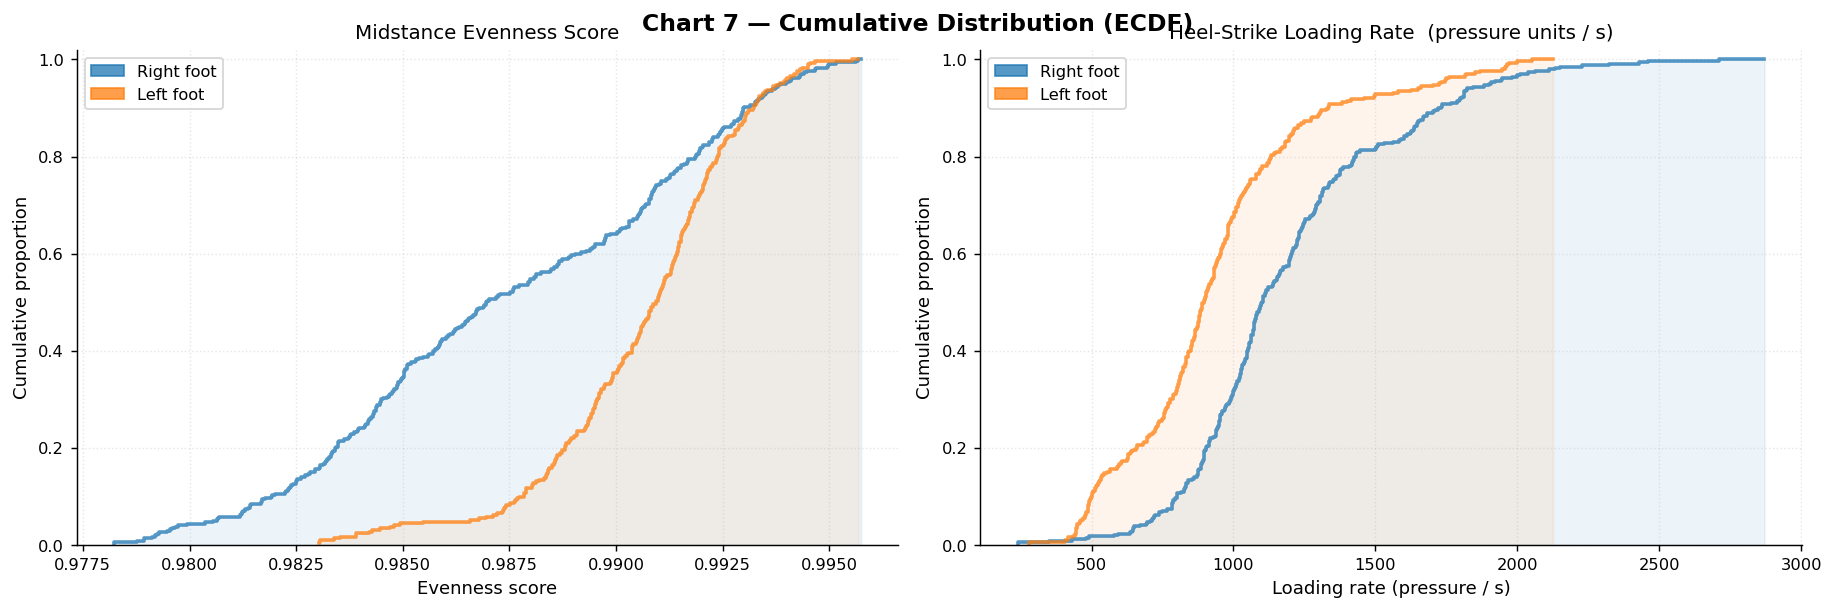

Saved → chart7_ecdf.png


In [11]:
fig, ax_e, ax_l = make_fig('Chart 7 — Cumulative Distribution (ECDF)')

for ax, df_m, metric, xlabel in [
    (ax_e, ent, 'evenness',     'Evenness score'),
    (ax_l, lr,  'loading_rate', 'Loading rate (pressure / s)'),
]:
    for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
        vals = np.sort(df_m[df_m.foot == foot][metric].values)
        cdf  = np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, cdf, color=color, lw=2, alpha=ALPHA, label=foot)
        ax.fill_between(vals, 0, cdf, color=color, alpha=0.08, step='pre')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Cumulative proportion')
    ax.set_ylim(0, 1.02)
    ax.legend(handles=foot_patches(), fontsize=9)

save(fig, 'chart7_ecdf.png')

## Cell 12 — Chart 8: Left–Right Symmetry per Matched Step Pair

Each left step is matched to the nearest right step in time.
The absolute difference is plotted — low = symmetric, high = asymmetric.

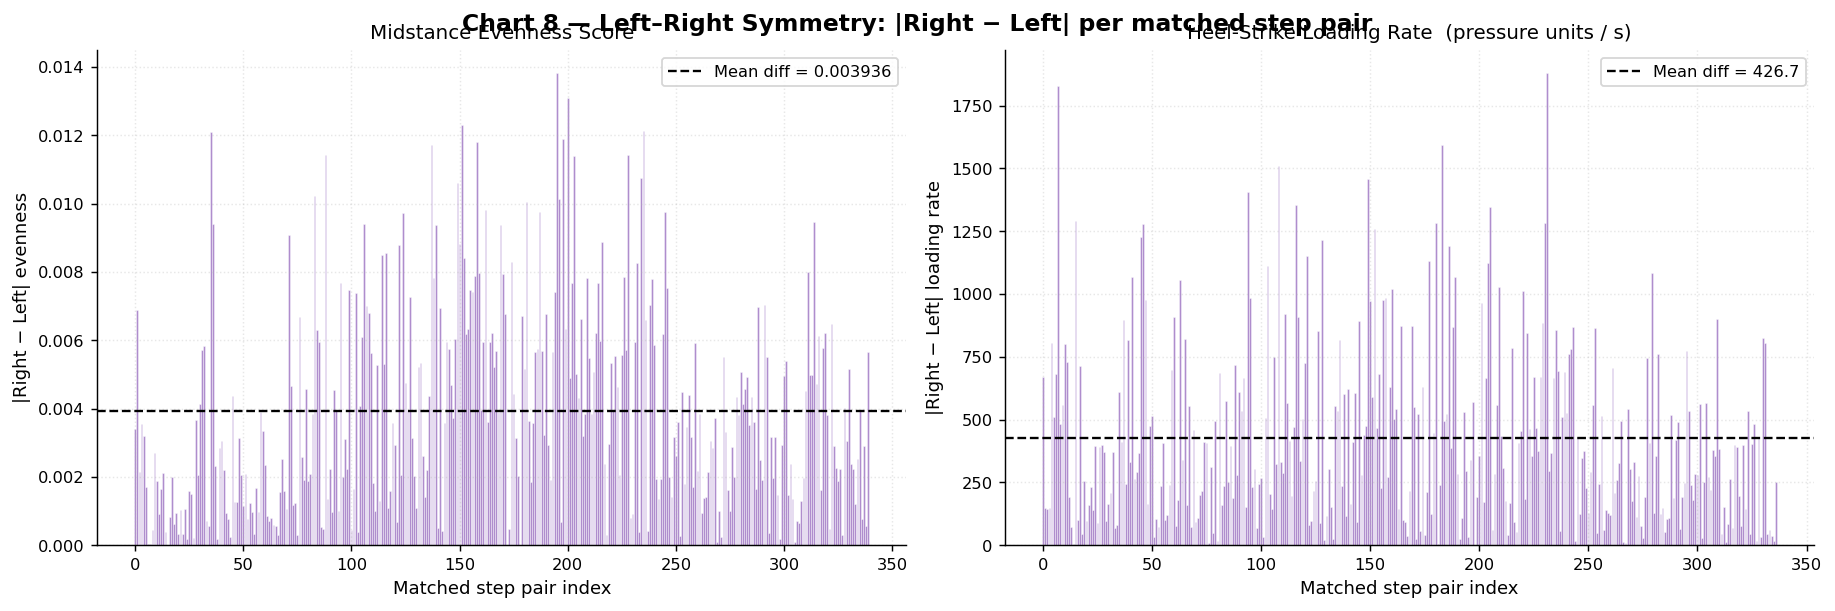

Saved → chart8_symmetry.png


In [12]:
fig, ax_e, ax_l = make_fig('Chart 8 — Left–Right Symmetry: |Right − Left| per matched step pair')

for ax, df_m, metric, ylabel in [
    (ax_e, ent, 'evenness',     '|Right − Left| evenness'),
    (ax_l, lr,  'loading_rate', '|Right − Left| loading rate'),
]:
    r = df_m[df_m.foot == 'Right'].sort_values('time_s').reset_index(drop=True)
    l = df_m[df_m.foot == 'Left'].sort_values('time_s').reset_index(drop=True)

    # Nearest-neighbour match each right step to a left step by time
    pairs = []
    for _, rrow in r.iterrows():
        idx  = (l['time_s'] - rrow['time_s']).abs().idxmin()
        lrow = l.loc[idx]
        pairs.append({'time_s': rrow['time_s'],
                      'diff': abs(rrow[metric] - lrow[metric])})
    pairs_df = pd.DataFrame(pairs)

    ax.bar(range(len(pairs_df)), pairs_df['diff'],
           color='#9467BD', alpha=ALPHA, edgecolor='white', linewidth=0.3)
    ax.axhline(pairs_df['diff'].mean(), color='black', ls='--', lw=1.3,
               label=f'Mean diff = {pairs_df["diff"].mean():.4g}')

    ax.set_xlabel('Matched step pair index')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

save(fig, 'chart8_symmetry.png')

## Cell 13 — Chart 9: Violin Plot — Shape + Density

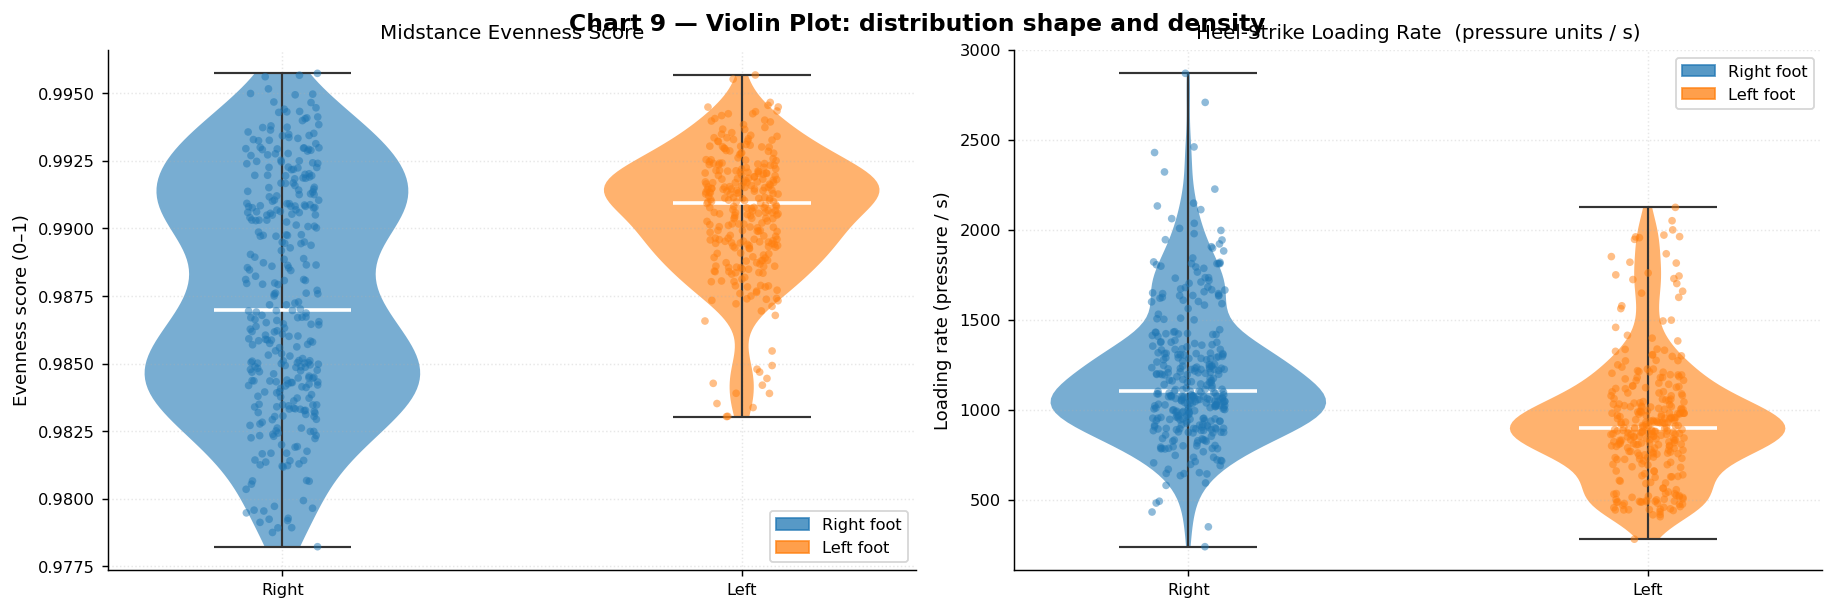

Saved → chart9_violin.png


In [13]:
fig, ax_e, ax_l = make_fig('Chart 9 — Violin Plot: distribution shape and density')

for ax, df_m, metric, ylabel in [
    (ax_e, ent, 'evenness',     'Evenness score (0–1)'),
    (ax_l, lr,  'loading_rate', 'Loading rate (pressure / s)'),
]:
    groups = [df_m[df_m.foot == f][metric].values for f in ['Right', 'Left']]
    vp = ax.violinplot(groups, positions=[1, 2], showmedians=True,
                       showextrema=True, widths=0.6)

    for body, color in zip(vp['bodies'], [C_RIGHT, C_LEFT]):
        body.set_facecolor(color)
        body.set_alpha(0.6)
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2)
    for part in ['cbars', 'cmins', 'cmaxes']:
        vp[part].set_color('#333333')
        vp[part].set_linewidth(1.2)

    # Overlay raw jittered points
    for i, (grp, color) in enumerate(zip(groups, [C_RIGHT, C_LEFT]), 1):
        jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(grp))
        ax.scatter(np.full(len(grp), i) + jitter, grp,
                   color=color, alpha=0.5, s=18, edgecolors='none', zorder=3)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Right', 'Left'])
    ax.set_ylabel(ylabel)
    ax.legend(handles=foot_patches(), fontsize=9)

save(fig, 'chart9_violin.png')

## Cell 14 — Chart 10: Dual-Metric Scatter — Entropy vs Loading Rate per Step

Each point is one step. Colour = foot. Shows whether higher loading rate
correlates with more or less even pressure distribution.

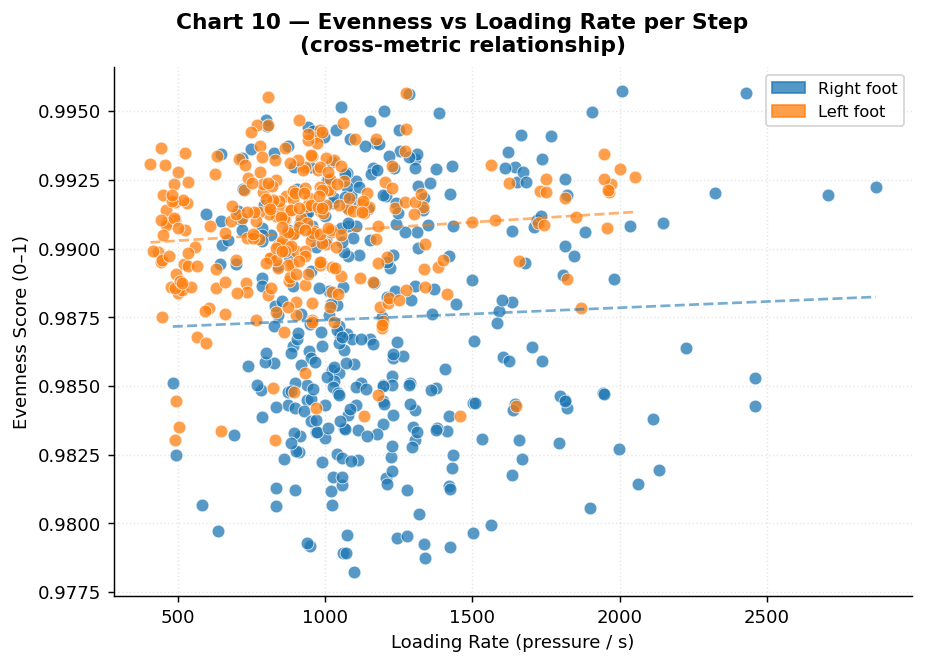

Saved → chart10_cross_scatter.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
fig.suptitle('Chart 10 — Evenness vs Loading Rate per Step\n'
             '(cross-metric relationship)', fontsize=12, fontweight='bold')

# Merge on nearest time within each foot
for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
    e = ent[ent.foot == foot].sort_values('time_s').reset_index(drop=True)
    l = lr[lr.foot == foot].sort_values('time_s').reset_index(drop=True)
    merged = pd.merge_asof(e[['time_s','evenness']],
                           l[['time_s','loading_rate']],
                           on='time_s', direction='nearest', tolerance=2.0)
    merged = merged.dropna()
    ax.scatter(merged['loading_rate'], merged['evenness'],
               color=color, alpha=ALPHA, s=50, label=foot,
               edgecolors='white', linewidths=0.5)
    # Trend line
    if len(merged) > 2:
        z = np.polyfit(merged['loading_rate'], merged['evenness'], 1)
        xr = np.linspace(merged['loading_rate'].min(), merged['loading_rate'].max(), 80)
        ax.plot(xr, np.polyval(z, xr), color=color, lw=1.5, ls='--', alpha=0.6)

ax.set_xlabel('Loading Rate (pressure / s)', fontsize=10)
ax.set_ylabel('Evenness Score (0–1)', fontsize=10)
ax.legend(handles=foot_patches(), fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

save(fig, 'chart10_cross_scatter.png')

## Cell 15 — Full Dashboard: all charts in one figure

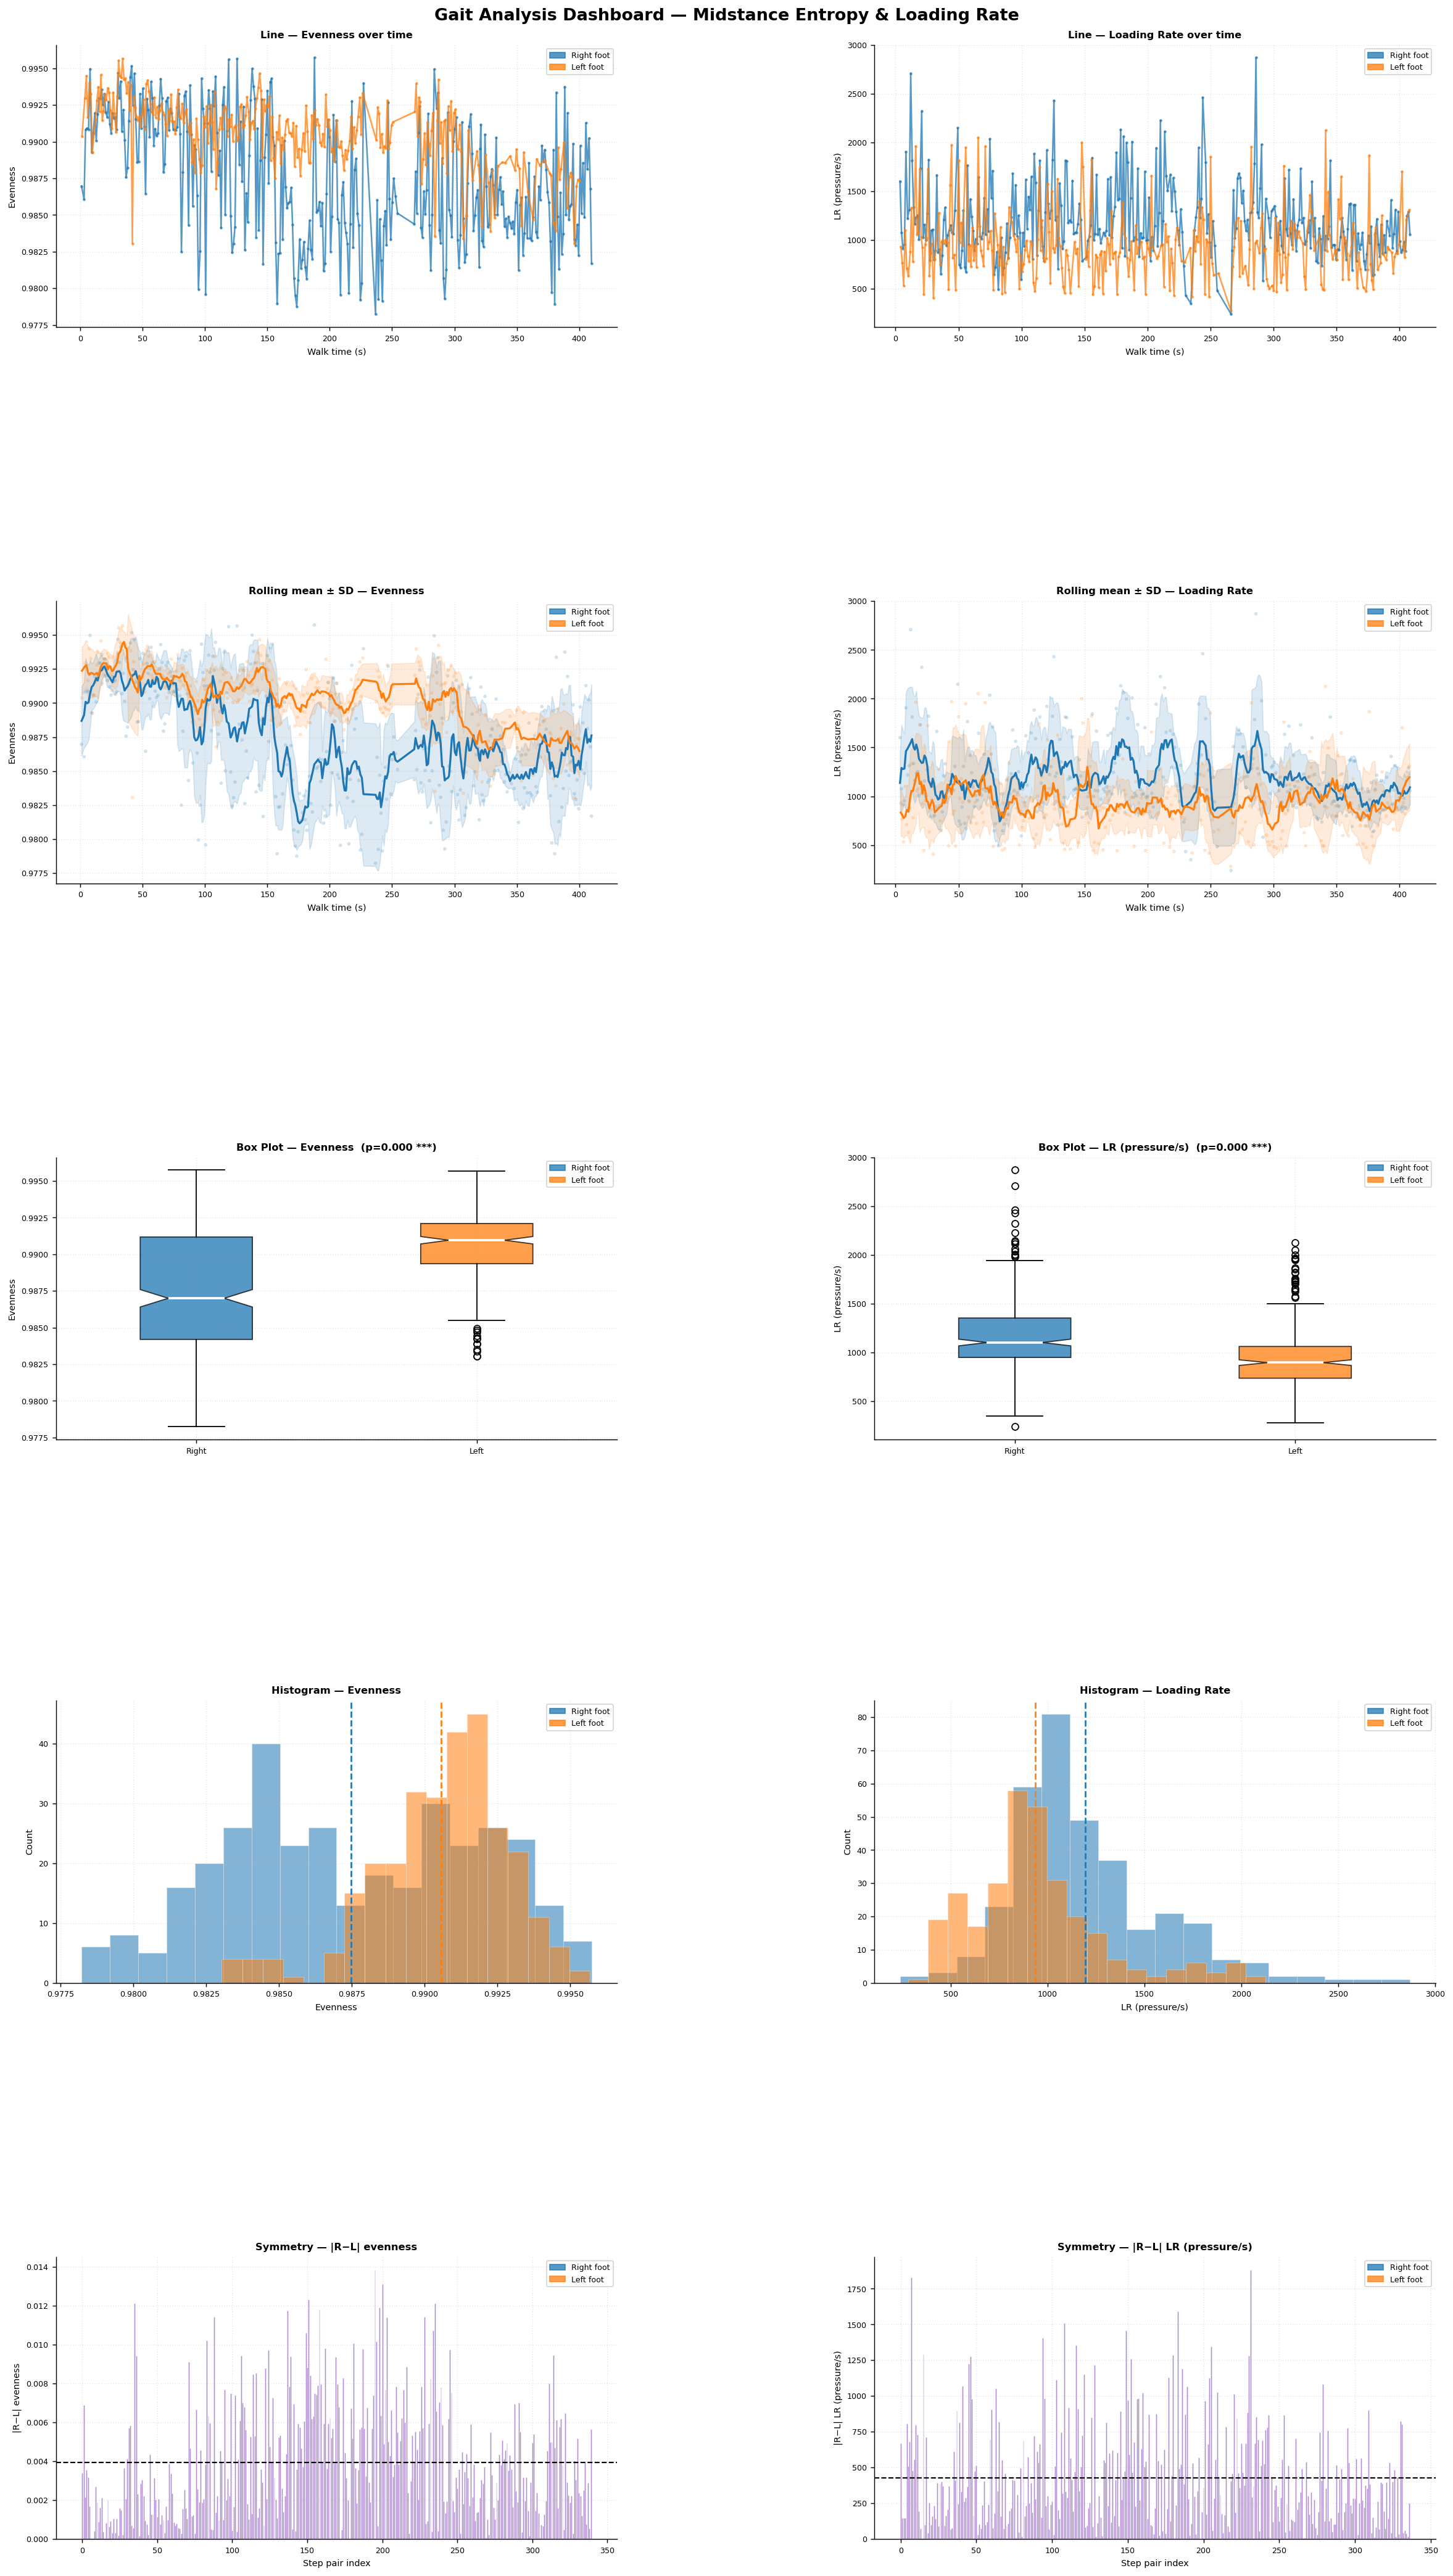

Saved → dashboard_full.png


In [15]:
fig = plt.figure(figsize=(18, 32), constrained_layout=True)
fig.suptitle('Gait Analysis Dashboard — Midstance Entropy & Loading Rate',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.3)

axes = {
    'line_e'  : fig.add_subplot(gs[0, 0]),
    'line_l'  : fig.add_subplot(gs[0, 1]),
    'roll_e'  : fig.add_subplot(gs[1, 0]),
    'roll_l'  : fig.add_subplot(gs[1, 1]),
    'box_e'   : fig.add_subplot(gs[2, 0]),
    'box_l'   : fig.add_subplot(gs[2, 1]),
    'hist_e'  : fig.add_subplot(gs[3, 0]),
    'hist_l'  : fig.add_subplot(gs[3, 1]),
    'sym_e'   : fig.add_subplot(gs[4, 0]),
    'sym_l'   : fig.add_subplot(gs[4, 1]),
}

def ann(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3, ls=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Row 1: line graphs ───────────────────────────────────────────────────────
for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
    d = ent[ent.foot == foot].sort_values('time_s')
    axes['line_e'].plot(d['time_s'], d['evenness'], color=color,
                        lw=1.4, alpha=ALPHA, marker='o', ms=2.5, markeredgewidth=0)
    d = lr[lr.foot == foot].sort_values('time_s')
    axes['line_l'].plot(d['time_s'], d['loading_rate'], color=color,
                        lw=1.4, alpha=ALPHA, marker='o', ms=2.5, markeredgewidth=0)
ann(axes['line_e'], 'Line — Evenness over time', 'Walk time (s)', 'Evenness')
ann(axes['line_l'], 'Line — Loading Rate over time', 'Walk time (s)', 'LR (pressure/s)')

# ── Row 2: rolling mean ──────────────────────────────────────────────────────
for (ax_key, df_m, metric) in [('roll_e', ent, 'evenness'), ('roll_l', lr, 'loading_rate')]:
    ax = axes[ax_key]
    for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
        d  = df_m[df_m.foot == foot].sort_values('time_s').reset_index(drop=True)
        mn = d[metric].rolling(8, center=True, min_periods=3).mean()
        sd = d[metric].rolling(8, center=True, min_periods=3).std()
        ax.plot(d['time_s'], mn, color=color, lw=1.8)
        ax.fill_between(d['time_s'], mn-sd, mn+sd, color=color, alpha=0.15)
        ax.scatter(d['time_s'], d[metric], color=color, alpha=0.2, s=10, edgecolors='none')
ann(axes['roll_e'], 'Rolling mean ± SD — Evenness', 'Walk time (s)', 'Evenness')
ann(axes['roll_l'], 'Rolling mean ± SD — Loading Rate', 'Walk time (s)', 'LR (pressure/s)')

# ── Row 3: box plots ─────────────────────────────────────────────────────────
for (ax_key, df_m, metric, ylabel) in [
    ('box_e', ent, 'evenness',     'Evenness'),
    ('box_l', lr,  'loading_rate', 'LR (pressure/s)'),
]:
    ax = axes[ax_key]
    groups = [df_m[df_m.foot == f][metric].values for f in ['Right','Left']]
    bp = ax.boxplot(groups, patch_artist=True, notch=True, widths=0.4,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], [C_RIGHT, C_LEFT]):
        patch.set_facecolor(color); patch.set_alpha(ALPHA)
    stat, p = mannwhitneyu(*groups, alternative='two-sided')
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    ax.set_title(f'Box Plot — {ylabel}  (p={p:.3f} {sig})', fontsize=9, fontweight='bold')
    ax.set_xticks([1,2]); ax.set_xticklabels(['Right','Left'], fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Row 4: histograms ────────────────────────────────────────────────────────
for (ax_key, df_m, metric, xlabel) in [
    ('hist_e', ent, 'evenness',     'Evenness'),
    ('hist_l', lr,  'loading_rate', 'LR (pressure/s)'),
]:
    ax = axes[ax_key]
    for foot, color in [('Right', C_RIGHT), ('Left', C_LEFT)]:
        v = df_m[df_m.foot == foot][metric].values
        ax.hist(v, bins=18, color=color, alpha=0.55, edgecolor='white', linewidth=0.3)
        ax.axvline(v.mean(), color=color, lw=1.5, ls='--')
ann(axes['hist_e'], 'Histogram — Evenness', 'Evenness', 'Count')
ann(axes['hist_l'], 'Histogram — Loading Rate', 'LR (pressure/s)', 'Count')

# ── Row 5: symmetry bars ─────────────────────────────────────────────────────
for (ax_key, df_m, metric, ylabel) in [
    ('sym_e', ent, 'evenness',     '|R−L| evenness'),
    ('sym_l', lr,  'loading_rate', '|R−L| LR (pressure/s)'),
]:
    ax = axes[ax_key]
    r = df_m[df_m.foot=='Right'].sort_values('time_s').reset_index(drop=True)
    l = df_m[df_m.foot=='Left'].sort_values('time_s').reset_index(drop=True)
    pairs = []
    for _, rrow in r.iterrows():
        idx = (l['time_s'] - rrow['time_s']).abs().idxmin()
        pairs.append(abs(rrow[metric] - l.loc[idx, metric]))
    ax.bar(range(len(pairs)), pairs, color='#9467BD', alpha=ALPHA,
           edgecolor='white', linewidth=0.3)
    ax.axhline(np.mean(pairs), color='black', ls='--', lw=1.2)
    ann(ax, f'Symmetry — {ylabel}', 'Step pair index', ylabel)

for ax in axes.values():
    ax.legend(handles=foot_patches(), fontsize=7, loc='best')

fig.savefig('dashboard_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dashboard_full.png')